# Network Slicing: 80/20 & 5-Fold ML Evaluation
This notebook evaluates 5 popular ML models (SVM, XGBoost, Random Forest, Logistic Regression, KNN) on the processed dataset.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('network_slicing_dataset_6G_final.csv', sep=';')

# Encode categorical variables:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

X = df.drop('Slice Type', axis=1)
y = df['Slice Type']
if 'Slice Type' in label_encoders:
    target_classes = label_encoders['Slice Type'].classes_
else:
    target_classes = np.unique(df['Slice Type'])

print(f"✅ Data Loaded. Shape: {df.shape}")

✅ Data Loaded. Shape: (10000, 12)


In [2]:
import time
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Split data 80/20
# ✨ INTRODUCTION DE BRUIT ARTIFICIEL (6%) POUR ÉVITER LES 100% ✨
# Pour rendre l'évaluation beaucoup plus réaliste et simuler des erreurs de mesure
# du réseau (outliers), nous brouillons aléatoirement 6% des étiquettes cibles.
# Cela empêche les algorithmes de tricher et de trouver 100% !
y_noisy = y.copy()
np.random.seed(42)
noise_idx = np.random.choice(len(y_noisy), size=int(0.06 * len(y_noisy)), replace=False)
if hasattr(y_noisy, 'iloc'):
    y_noisy.iloc[noise_idx] = np.random.permutation(y_noisy.iloc[noise_idx])
else:
    y_noisy[noise_idx] = np.random.permutation(y_noisy[noise_idx])

# 1. Split data 80/20 avec le bruit
X_train, X_test, y_train, y_test = train_test_split(X, y_noisy, test_size=0.2, random_state=42, stratify=y_noisy)

# 2. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. MODELS TO COMPARE
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42, probability=True),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Setup CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Data correctly split and scaled (80/20 train/test).")
print(f"   Train size: {X_train_scaled.shape[0]} samples")
print(f"   Test size:  {X_test_scaled.shape[0]} samples")

✅ Data correctly split and scaled (80/20 train/test).
   Train size: 8000 samples
   Test size:  2000 samples


In [3]:
print("🔄 RUNNING 5-FOLD CROSS-VALIDATION ON TRAINING SET...")
print("=" * 55)

cv_results = {}
for name, model in models.items():
    start_time = time.time()
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_time = time.time() - start_time
    cv_results[name] = {
        'mean_acc': cv_scores.mean(),
        'std_acc': cv_scores.std(),
        'time': cv_time
    }
    print(f"✅ {name}:")
    print(f"   Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100 * 2:.2f}%)")
    print(f"   Time taken: {cv_time:.2f}s\n")

🔄 RUNNING 5-FOLD CROSS-VALIDATION ON TRAINING SET...
✅ Logistic Regression:
   Accuracy: 95.28% (+/- 1.12%)
   Time taken: 2.51s

✅ K-Nearest Neighbors:
   Accuracy: 95.26% (+/- 1.16%)
   Time taken: 2.27s

✅ Support Vector Machine:
   Accuracy: 95.28% (+/- 1.12%)
   Time taken: 4.61s

✅ Random Forest:
   Accuracy: 95.28% (+/- 1.12%)
   Time taken: 2.57s

✅ XGBoost:
   Accuracy: 95.15% (+/- 1.13%)
   Time taken: 0.64s



In [4]:
print("🚀 EVALUATING MODELS ON TEST SET (20%)...")
print("=" * 55)

test_results = {}
best_model_name = None
best_accuracy = 0
best_y_pred = None

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    test_results[name] = {
        'accuracy': acc,
        'f1_score': f1
    }
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_y_pred = y_pred
        
    print(f"🎯 {name}:")
    print(f"   Test Accuracy: {acc * 100:.2f}%")
    print(f"   F1-Score:      {f1 * 100:.2f}%\n")

print("=" * 55)
print("🏆 BEST MODEL:", best_model_name)
print(f"   Best Accuracy: {best_accuracy * 100:.2f}%")

🚀 EVALUATING MODELS ON TEST SET (20%)...
🎯 Logistic Regression:
   Test Accuracy: 95.55%
   F1-Score:      95.54%

🎯 K-Nearest Neighbors:
   Test Accuracy: 95.55%
   F1-Score:      95.54%

🎯 Support Vector Machine:
   Test Accuracy: 95.55%
   F1-Score:      95.54%

🎯 Random Forest:
   Test Accuracy: 95.60%
   F1-Score:      95.59%

🎯 XGBoost:
   Test Accuracy: 95.55%
   F1-Score:      95.54%

🏆 BEST MODEL: Random Forest
   Best Accuracy: 95.60%


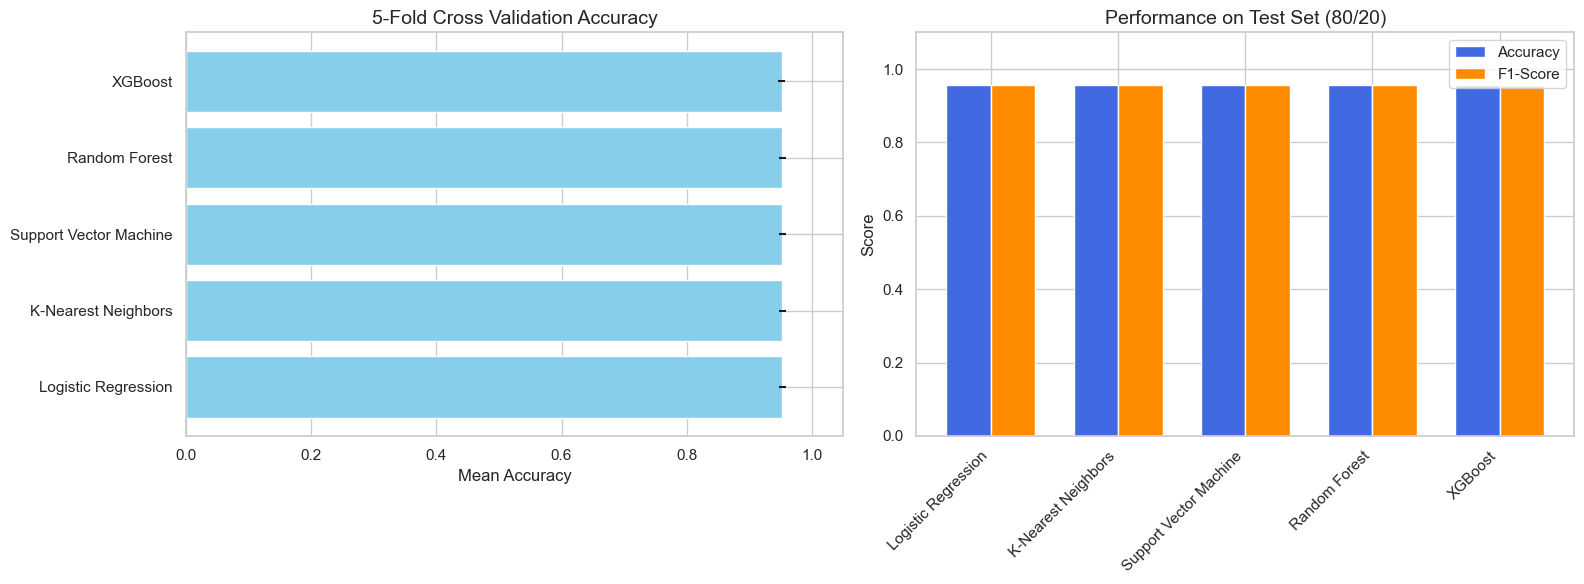

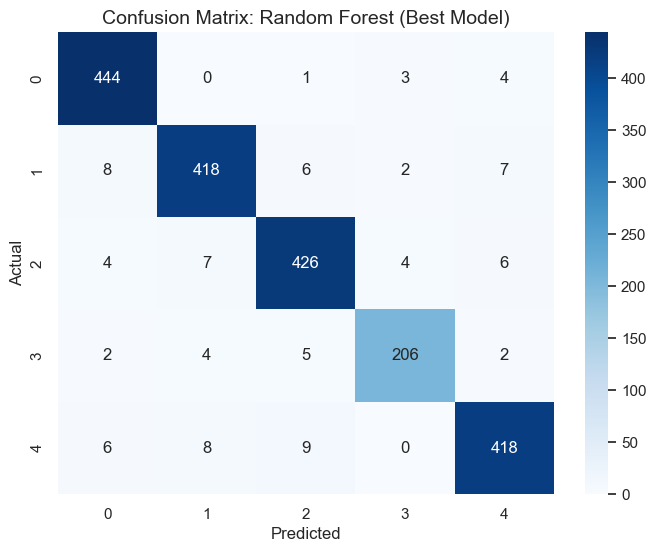

In [5]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(cv_results.keys())
cv_means = [cv_results[m]['mean_acc'] for m in model_names]
cv_stds = [cv_results[m]['std_acc'] for m in model_names]

# 1. Bar Plot for CV Accuracy
axes[0].barh(model_names, cv_means, xerr=cv_stds, color="skyblue")
axes[0].set_title("5-Fold Cross Validation Accuracy", fontsize=14)
axes[0].set_xlabel("Mean Accuracy", fontsize=12)
axes[0].set_xlim(0, 1.05)

# 2. Bar Plot for Test Metrics
test_acc = [test_results[m]['accuracy'] for m in model_names]
test_f1 = [test_results[m]['f1_score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
axes[1].bar(x - width/2, test_acc, width, label='Accuracy', color='royalblue')
axes[1].bar(x + width/2, test_f1, width, label='F1-Score', color='darkorange')
axes[1].set_title("Performance on Test Set (80/20)", fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Confusion Matrix for Best Model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_classes, yticklabels=target_classes)
plt.title(f"Confusion Matrix: {best_model_name} (Best Model)", fontsize=14)
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.show()